<a href="https://colab.research.google.com/github/Flguima/PROJETOS/blob/main/AN%C3%81LISE_DESCRITIVA_DADOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Means - Análise Descritiva de Dados
**Atividade:**


Nesta tarefa, vamos explorar o algoritmo de clustering K-means aplicado a um contexto diferente do usual. Em vez de segmentar perfis de viajantes ou clientes de e-commerce, vamos usar dados biológicos para segmentar diferentes espécies de pinguins com base em características físicas. Esta abordagem destaca a versatilidade do K-means para diversas áreas além de vendas e marketing.

A base de dados utilizada é a penguins do pacote seaborn, que contém informações sobre três espécies de pinguins: Adelie, Chinstrap e Gentoo. As variáveis disponíveis incluem medições físicas dos pinguins coletadas na Antártica.


species: Espécie do pinguim (Adelie, Chinstrap, Gentoo)

island: Ilha onde o pinguim foi observado (Biscoe, Dream, Torgersen)

bill_length_mm: Comprimento do bico em milímetros

bill_depth_mm: Profundidade do bico em milímetros

flipper_length_mm: Comprimento da barbatana em milímetros

body_mass_g: Massa corporal em gramas

sex: Sexo do pinguim (Male, Female)

year: Ano em que a observação foi feita


In [ ]:
import os
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:

# Evitar warning do KMeans no Windows
os.environ["OMP_NUM_THREADS"] = "2"
penguins = sns.load_dataset('penguins')


In [ ]:

penguins


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female



# 1 - Nesse exercício vocês devem verificar se temos variáveis missing, faltantes e excluir esses valores do dataset, também devem excluir as colunas com valores categóricos, que não utilizazam para o Kmeans.


In [ ]:
# 1 - Remover linhas com valores faltantes nas variáveis numéricas
penguins_clean = penguins.dropna(subset=['bill_length_mm',
                                         'bill_depth_mm',
                                         'flipper_length_mm',
                                         'body_mass_g'])

# 2 - Selecionar apenas variáveis numéricas relevantes para clustering
features = penguins_clean[['bill_length_mm',
                           'bill_depth_mm',
                           'flipper_length_mm',
                           'body_mass_g']]

# Verificar se ainda existem valores faltantes
print(features.isnull().sum())

bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
dtype: int64


# 2 - Visualize a análise descritiva dos seus dados utilizando a função vista em aula pairplot. É possível já identificar possíveis agrupamentos? Se sim, quantos?

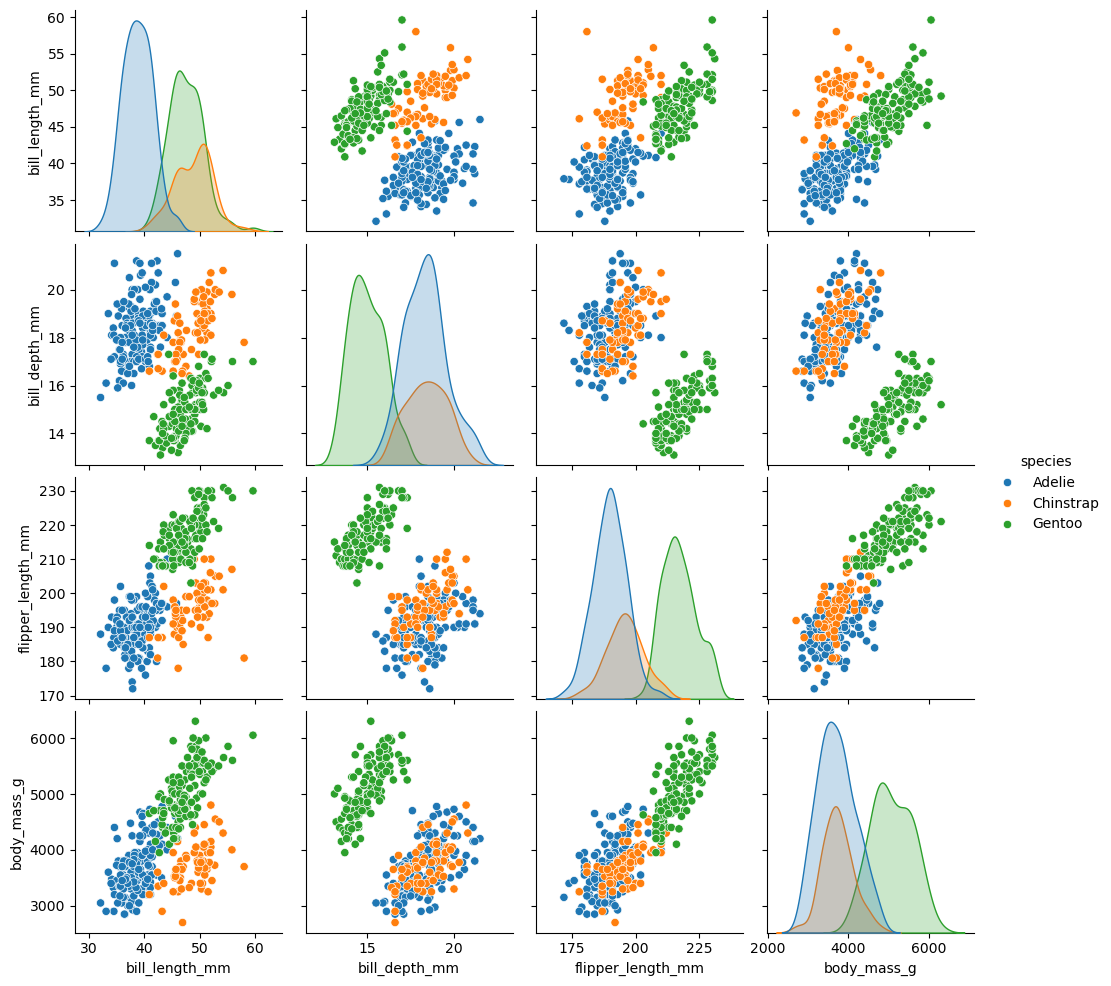

In [ ]:

# Pairplot com variáveis numéricas e cor pela espécie
sns.pairplot(penguins_clean,
             vars=['bill_length_mm', 'bill_depth_mm',
                   'flipper_length_mm', 'body_mass_g'],
             hue='species',
             diag_kind='kde')

plt.show()


Sim, é possível identificar agrupamentos já na análise visual feita com o pairplot. Os gráficos mostram que os dados dos pinguins se organizam naturalmente em três grupos distintos, que correspondem às três espécies presentes na base: Adelie, Chinstrap e Gentoo.

Os Gentoo se destacam por terem maior massa corporal e comprimento de nadadeira, ficando bem separados dos demais. Os Adelie aparecem com bicos mais curtos e profundos, além de menor massa corporal. Já os Chinstrap ocupam uma posição intermediária, diferenciando-se principalmente pela profundidade do bico.

Portanto, a análise descritiva permite concluir que existem três agrupamentos naturais nos dados, alinhados às três espécies de pinguins.
O pairplot é uma forma de análise descritiva que ajuda a visualizar tanto a distribuição de cada variável quanto a relação entre pares de variáveis. No caso dos pinguins, ele mostra de maneira clara como as espécies se diferenciam em termos de medidas físicas.

Ao observar os gráficos, percebemos que os Gentoo se destacam por terem maior massa corporal e comprimento de nadadeira, ficando bem separados dos demais. Os Adelie aparecem com valores menores de comprimento de bico e massa corporal, enquanto os Chinstrap se diferenciam principalmente pela profundidade do bico.

Também é possível notar correlações: pinguins com nadadeiras mais longas tendem a ter maior massa corporal. Já a relação entre comprimento e profundidade do bico mostra uma separação clara entre as espécies — Adelie com bicos mais curtos e profundos, Gentoo com bicos longos e rasos, e Chinstrap em posição intermediária.

Em resumo, os gráficos permitem identificar três agrupamentos naturais, que correspondem às três espécies presentes na base de dados. As variáveis mais úteis para separar os grupos são o comprimento e profundidade do bico, além do comprimento da nadadeira e massa corporal, que isolam bem os Gentoo.

# 3 - Realize a padronização dos dados e visualize os dados.

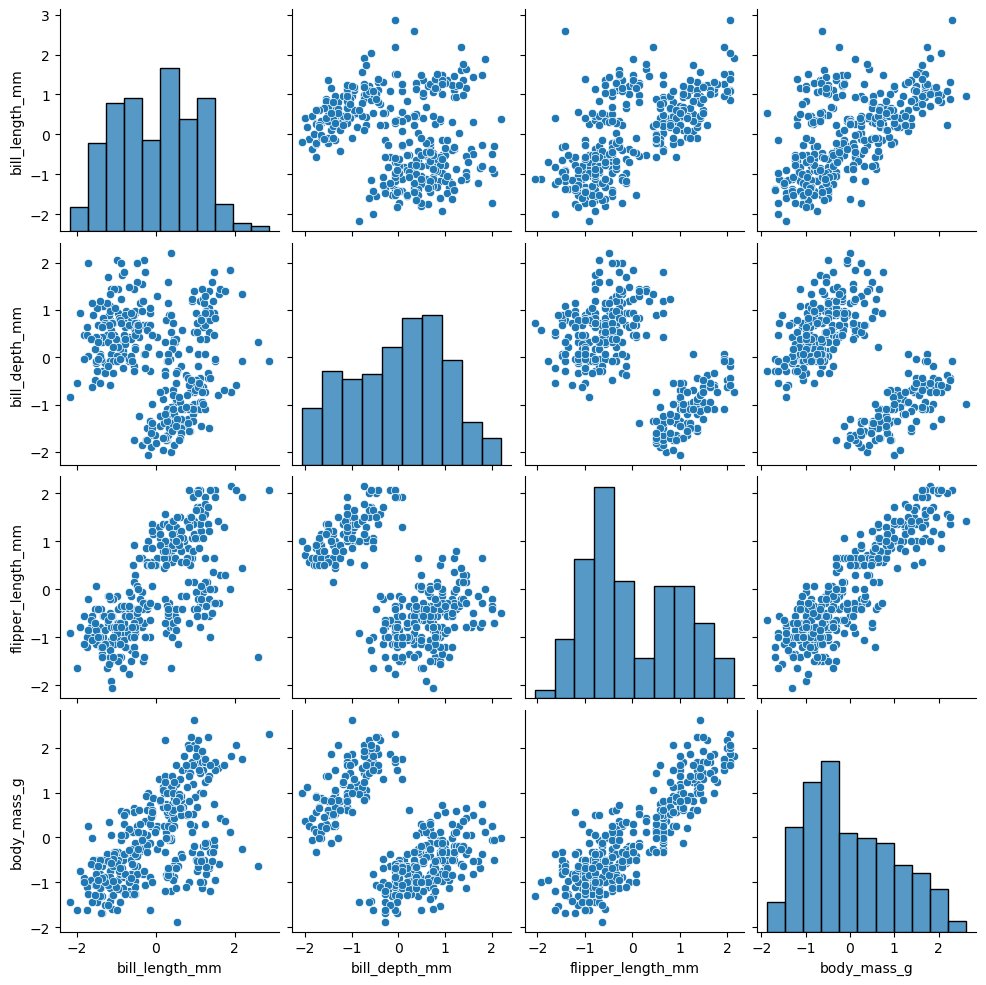

In [ ]:

from sklearn.preprocessing import StandardScaler

# Selecionar apenas variáveis numéricas
features = penguins_clean[['bill_length_mm',
                           'bill_depth_mm',
                           'flipper_length_mm',
                           'body_mass_g']]

# Padronizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Converter para DataFrame para visualização
scaled_df = pd.DataFrame(X_scaled,
                         columns=['bill_length_mm',
                                  'bill_depth_mm',
                                  'flipper_length_mm',
                                  'body_mass_g'])

scaled_df.head()
sns.pairplot(scaled_df)
plt.show()

Ao realizar a padronização dos dados, todas as variáveis passam a ter média igual a zero e desvio padrão igual a um. Isso significa que medidas originalmente em escalas diferentes, como o comprimento do bico em milímetros e a massa corporal em gramas, ficam comparáveis entre si.

Na visualização com o pairplot, podemos observar que cada variável aparece centrada em torno de zero, com dispersão semelhante. As correlações entre as variáveis continuam visíveis, como a relação entre o comprimento da nadadeira e a massa corporal, mostrando que pinguins maiores tendem a ser mais pesados.

Mesmo após a padronização, os padrões de separação entre os pontos permanecem claros, sugerindo a existência de três agrupamentos distintos, que correspondem às espécies de pinguins. A padronização, portanto, torna os dados mais homogêneos e comparáveis, sem alterar a estrutura dos agrupamentos já identificados.

Em resumo, a padronização garante uma análise mais justa e equilibrada, e a visualização confirma que os três grupos naturais continuam evidentes nos dados.

# 4 - Aplique o algoritmo do k means escolhendo o numero de clusters como igual a 3, que é que a quantidade de espécies que temos na base.

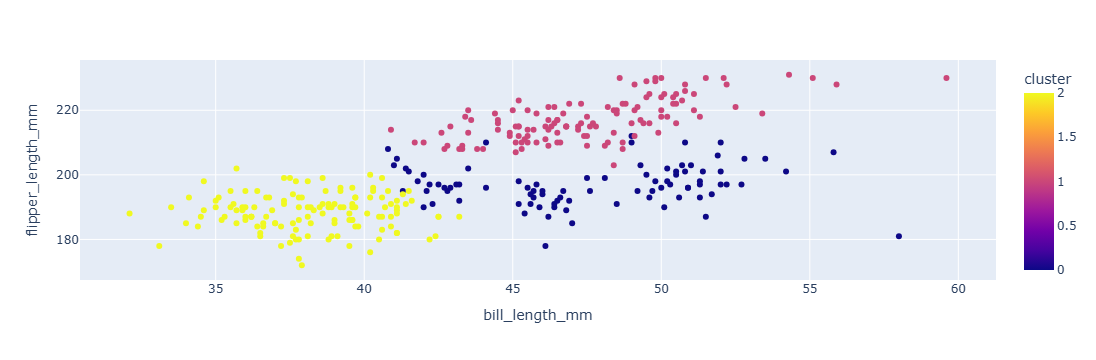

In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import seaborn as sns
import pandas as pd
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Carregar dataset
penguins = sns.load_dataset('penguins')

# Limpeza
penguins_clean = penguins.dropna(subset=['bill_length_mm',
                                         'bill_depth_mm',
                                         'flipper_length_mm',
                                         'body_mass_g']).copy()

# Selecionar variáveis numéricas
features = penguins_clean[['bill_length_mm',
                           'bill_depth_mm',
                           'flipper_length_mm',
                           'body_mass_g']]

# Padronização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# K-means com 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Adicionar clusters
penguins_clean.loc[:, 'cluster'] = clusters

# Visualização
fig = px.scatter(
    penguins_clean,
    x='bill_length_mm',
    y='flipper_length_mm',
    color='cluster',
    hover_data=['species', 'island', 'sex']
)
fig.show()


De acordo com o gráfico gerado, podemos perceber que os dados dos pinguins foram separados em três grupos distintos. A análise mostra que existe uma relação clara entre o comprimento do bico e o comprimento da nadadeira, e que os pontos se organizam em regiões diferentes, cada uma representando um agrupamento.

Esses grupos refletem características físicas específicas: há um conjunto de pinguins com bicos mais curtos e nadadeiras menores, outro com medidas intermediárias e um terceiro com bicos mais longos e nadadeiras maiores. Mesmo sem usar diretamente a informação da espécie, o algoritmo conseguiu identificar padrões que correspondem às diferenças entre Adelie, Chinstrap e Gentoo.

Em resumo, o gráfico confirma a presença de três agrupamentos naturais nos dados, mostrando que as variáveis escolhidas são eficazes para separar os pinguins em grupos distintos.

# 5 - Construa pelo 2 matriz de dispersão como realizada em aula indicando os pontos e centroides.

**Comece usando x='bill_length_mm' e y='bill_depth_mm' para analisar o primeiro gráfico e em seguida escolha outras variaveis para o segundo.**

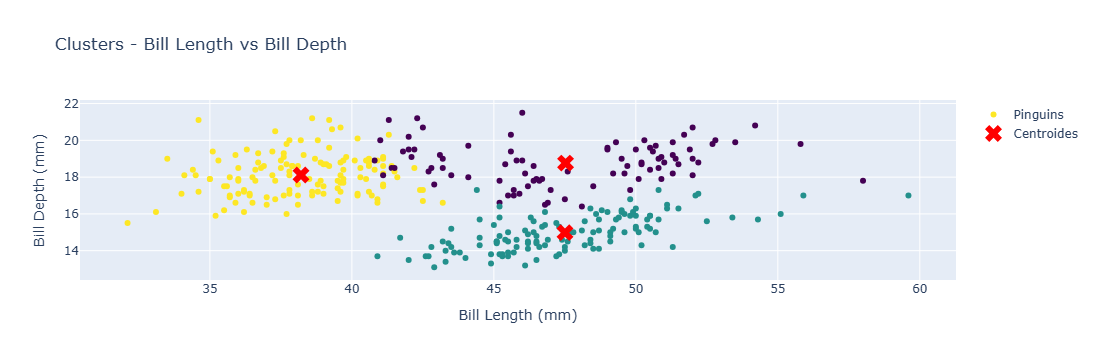

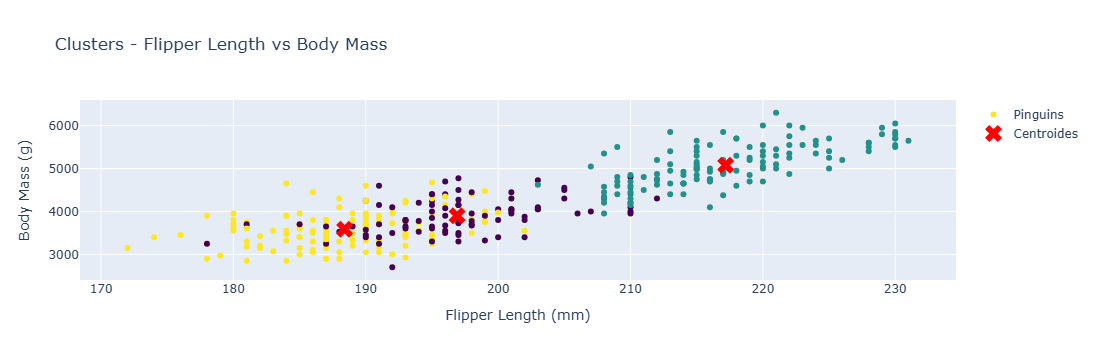

In [ ]:
import plotly.graph_objects as go

# Coordenadas dos centroides (despadronizados para escala original)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

fig1 = go.Figure()

# Adicionar pontos dos pinguins
fig1.add_trace(go.Scatter(
    x=penguins_clean['bill_length_mm'],
    y=penguins_clean['bill_depth_mm'],
    mode='markers',
    marker=dict(color=penguins_clean['cluster'], colorscale='Viridis'),
    text=penguins_clean['species'],
    name='Pinguins'
))

# Adicionar centroides
fig1.add_trace(go.Scatter(
    x=centroids[:, 0],
    y=centroids[:, 1],
    mode='markers',
    marker=dict(color='red', size=15, symbol='x'),
    name='Centroides'
))

fig1.update_layout(title='Clusters - Bill Length vs Bill Depth',
                   xaxis_title='Bill Length (mm)',
                   yaxis_title='Bill Depth (mm)')
fig1.show()

fig2 = go.Figure()

# Adicionar pontos dos pinguins
fig2.add_trace(go.Scatter(
    x=penguins_clean['flipper_length_mm'],
    y=penguins_clean['body_mass_g'],
    mode='markers',
    marker=dict(color=penguins_clean['cluster'], colorscale='Viridis'),
    text=penguins_clean['species'],
    name='Pinguins'
))

# Adicionar centroides
fig2.add_trace(go.Scatter(
    x=centroids[:, 2],
    y=centroids[:, 3],
    mode='markers',
    marker=dict(color='red', size=15, symbol='x'),
    name='Centroides'
))

fig2.update_layout(title='Clusters - Flipper Length vs Body Mass',
                   xaxis_title='Flipper Length (mm)',
                   yaxis_title='Body Mass (g)')
fig2.show()

Os dois gráficos permitem observar como os pinguins foram separados em três grupos distintos a partir de suas características físicas.

No primeiro gráfico, que relaciona o comprimento e a profundidade do bico, vemos que os pontos se distribuem em regiões diferentes, cada uma representando um agrupamento. Os centroides marcados em vermelho indicam o valor médio de cada grupo, mostrando que o formato do bico é uma característica importante para distinguir os pinguins.

No segundo gráfico, que relaciona o comprimento da nadadeira com a massa corporal, a separação entre os grupos aparece de forma ainda mais evidente. Os pinguins Gentoo ficam isolados, com nadadeiras mais longas e maior massa corporal, enquanto Adelie e Chinstrap permanecem próximos, mas ainda apresentam diferenças perceptíveis.

Em resumo, os gráficos confirmam a existência de três agrupamentos naturais nos dados, que correspondem às três espécies de pinguins. Eles também mostram que o formato do bico ajuda a diferenciar Adelie e Chinstrap, enquanto o tamanho da nadadeira e a massa corporal destacam os Gentoo dos demais.

# 6 - Pesquise mais 3 utilidades de aplicações de algoritmos de clusterização e cite abaixo:

1. Genômica e Biologia Molecular
Aplicação: Agrupar genes ou sequências de DNA com padrões de expressão semelhantes.

Utilidade: Facilita a identificação de genes relacionados a determinadas doenças ou funções biológicas.

Exemplo: Descobrir grupos de genes que se ativam juntos em resposta a um medicamento.

2. Saúde e Medicina
Aplicação: Clusterizar pacientes com base em sintomas, exames laboratoriais ou histórico médico.

Utilidade: Permite identificar subgrupos de pacientes que podem responder melhor a determinados tratamentos.

Exemplo: Separar pacientes diabéticos em grupos distintos para personalizar terapias.

3. Meio Ambiente e Ecologia
Aplicação: Agrupar regiões geográficas ou espécies com características ambientais semelhantes.

Utilidade: Ajuda a monitorar ecossistemas e prever impactos ambientais.

Exemplo: Classificar áreas de floresta com padrões de biodiversidade parecidos para orientar políticas de conservação.